# 랭체인(LangChain) Compression 예제 - PatentGPT
## 작성자 : AISchool ( http://aischool.ai/%ec%98%a8%eb%9d%bc%ec%9d%b8-%ea%b0%95%ec%9d%98-%ec%b9%b4%ed%85%8c%ea%b3%a0%eb%a6%ac/ )
## 특허 데이터 다운받기 : https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=547

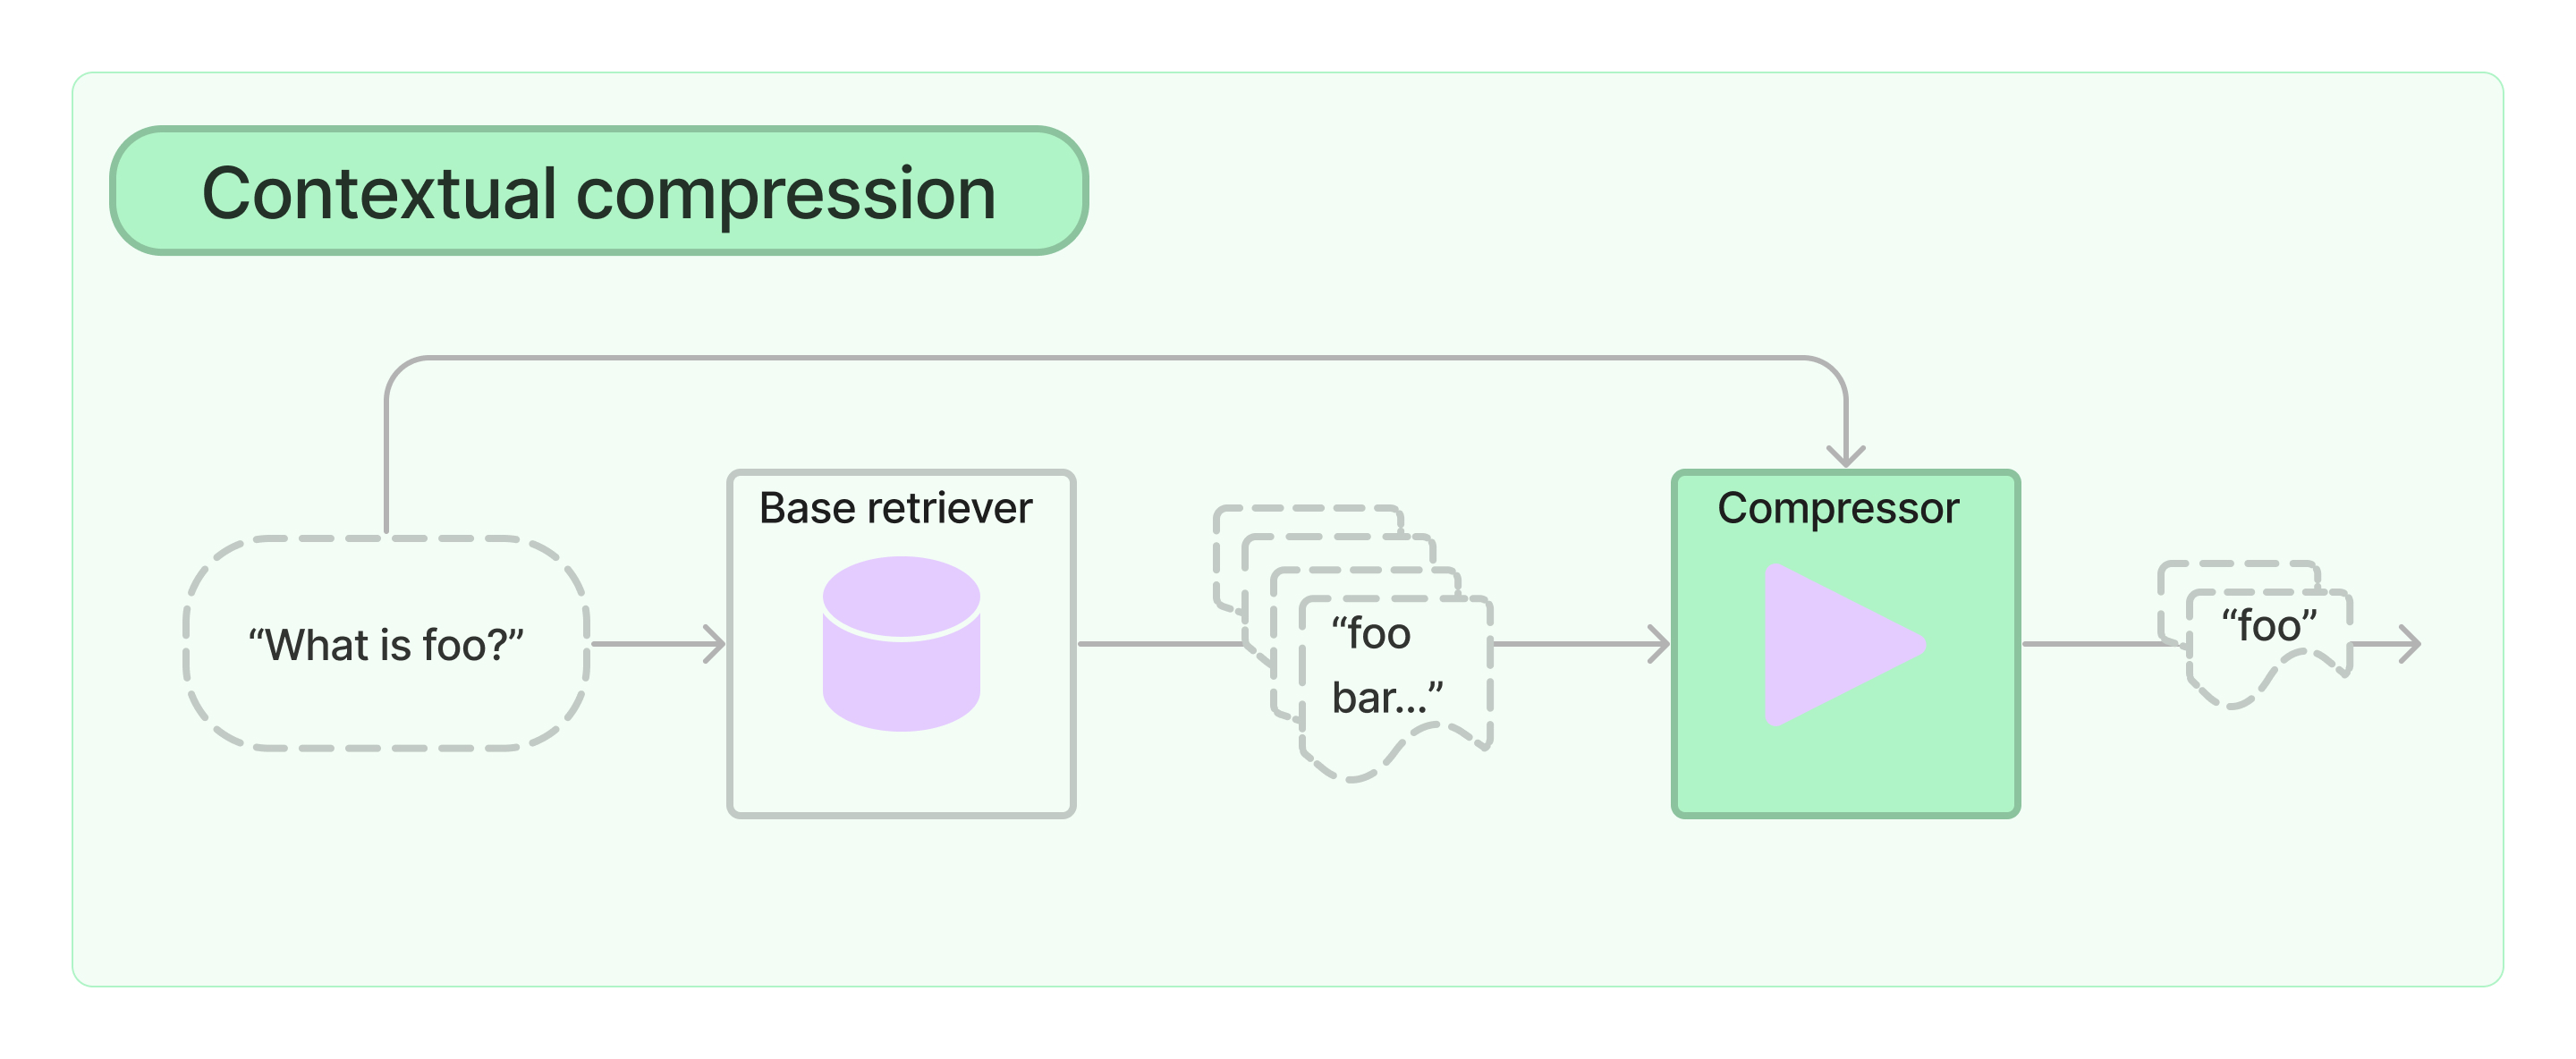

# 특허 데이터 다운로드 & 업로드하기

In [ ]:
# /032.특허 분야 자동분류 데이터/01.데이터/2.Validation/원천데이터/VS1/J_정보통신업_58_63/62_컴퓨터프로그래밍_시스템통합및관리업/620_컴퓨터프로그래밍_시스템통합및관리업/
# 62010_컴퓨터프로그래밍서비스업.json

In [ ]:
#특허자동분류 압축풀기
# 분할된 파일들을 하나로 합치기 (cat 명령어 사용)
!cat VS1.zip.part* > VS1_combined.zip

# 합쳐진 파일 압축 풀기
!unzip VS1_combined.zip

# LangChain 라이브러리 설치

In [ ]:
!apt-get install -y jq libmagic-dev poppler-utils tesseract-ocr
!pip install -q -U langchain langchain-community langchain-openai langchain-chroma langchain-huggingface chromadb tiktoken pypdf unstructured sentence-transformers jq

# 컴퓨터프로그래밍서비스업 특허 데이터 읽어오기

In [ ]:
from langchain_community.document_loaders import JSONLoader

# 62010_컴퓨터프로그래밍서비스업.json
loader = JSONLoader(
    file_path='./62010_컴퓨터프로그래밍서비스업.json',
    jq_schema='.dataset[]',
    text_content=False)
docs = loader.load()
docs

# 한글 인코딩 처리

In [ ]:
from langchain_community.docstore.document import Document

refined_docs = []

# 유니코드 이스케이프 시퀀스를 정상적인 문자열로 변환
for idx, doc in enumerate(docs):
    broken_korean = doc.page_content
    fixed_korean = broken_korean.encode('latin1').decode('unicode-escape')

    refined_doc = Document(page_content=fixed_korean)
    refined_docs.append(refined_doc)


    print(idx, fixed_korean)

In [ ]:
len(refined_docs)

In [ ]:
refined_docs[0]

In [ ]:
#JSON 파일 임베딩 작업
from langchain_community.embeddings import HuggingFaceEmbeddings

model_name = "jhgan/ko-sroberta-multitask" # (KorNLU 데이터셋에 학습시킨 한국어 임베딩 모델)
model_kwargs = {'device': 'cpu'}
encode_kwargs = {'normalize_embeddings': False}
embedding_model = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

In [ ]:
#임베딩 작업이 완료된 파일 벡터스토어에 저장
from langchain_chroma import Chroma

#vectorstore.delete_collection()  # Collection 삭제
vectorstore = Chroma.from_documents(
    documents=refined_docs,
    embedding=embedding_model
)

# Vector Stores를 이용해 연관된 특허 찾기

In [ ]:
retriever = vectorstore.as_retriever()

In [ ]:
from pprint import pprint

retrieved_docs = retriever.invoke(
    "GPS 관련 관련 특허에 대해 알려줘"
)
pprint(retrieved_docs[0].page_content)

In [ ]:
retrieved_docs = retriever.invoke(
    "IoT 관련 관련 특허에 대해 알려줘"
)
pprint(retrieved_docs[0].page_content)

In [ ]:
len(refined_docs)

# 출원 번호 확인하기

In [ ]:
import json
for idx, doc in enumerate(refined_docs):
    if idx >= 10:
        break
    # JSON 포맷으로 변환
    data_json = json.loads(doc.page_content)
    application_number = data_json.get("application_number")
    invention_title = data_json.get("invention_title")

    print(idx, application_number, invention_title)

# 특허 상세내용 검색하기
## 특허에 대한 상세한 내용을 검색할 수 있는 사이트 : http://www.kipris.or.kr/khome/main.jsp
## 미리 다운로드한 10개의 특허 상세내용 pdf 파일 : https://drive.google.com/file/d/1Y8_yclwMl3adUzYY4OyQuYlG9z-LPZg_/view?usp=drive_link

In [ ]:
!unzip patent_detail.zip

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

each_pdf_document = []
for idx, doc in enumerate(refined_docs):
    if idx >= 10:
        break
    # JSON 포맷으로 변환
    data_json = json.loads(doc.page_content)
    application_number = data_json.get("application_number")
    invention_title = data_json.get("invention_title")

    # pdf 정보 가져오기
    loader = PyPDFLoader(f"/content/patent_detail/{application_number}.pdf")
    pages = loader.load()
    total_page_string = ''
    for page in pages:
        total_page_string = total_page_string + page.page_content
    #print(total_page_string)
    each_pdf_document.append(Document(page_content=total_page_string, metadata={'application_number':f'{application_number}'}))

    print(idx, application_number, invention_title)

In [ ]:
len(each_pdf_document)

In [ ]:
each_pdf_document[0]

# 2. metadata 검색을 통해 자세한 특허정보 찾기

In [ ]:
def find_patent_detail(application_number):
    for doc in each_pdf_document:
      if doc.metadata["application_number"] == application_number:
          return doc.page_content

In [ ]:
# 0 1020170034399 캐쉬백 서비스 방법 및 이를 실행하는 사업자 서버
# 1 1020170038768 인터넷 결제 시스템
# 2 1020170039249 군 정찰용 무인기의 서비스정보 환경 구축 및 군 상황도를 활용한 서비스호출 연계 방법 및 시스템
# 3 1020170045321 프로토콜을 이용한 자동차 코딩 자가체크 시스템 개발
# 4 1020170061303 다계층 실행 기반 병렬형 소프트웨어 개발 시스템 및 방법
# 5 1020170064969 커뮤니티 관리 시스템
# 6 1020170066345 웹 서비스 애플리케이션 개발을 위한 서버측 프레임워크 장치, 이에 의해 개발된 웹 서비스 애플리케이션의 실행 방법 및 이를 위한 컴퓨터 프로그램
# 7 1020170077144 온-오프라인 연계 회원 등록 및 관리방법 및 시스템
# 8 1020170079788 제품 관리 시스템 및 제품 관리 운용 방법
# 9 1020170085786 포토북 편집 소프트웨어의 브라우저 편집 시스템 및 그 편집방법

In [ ]:
from pprint import pprint

retrievered_docs = retriever.invoke(
    "군 정찰용 무인기 관련 특허에 대해 알려줘"
)
pprint(retrievered_docs[0].page_content)

In [ ]:
# 출원번호 1020170034399 캐쉬백 서비스 방법 및 이를 실행하는 사업자 서버 특허 상세정보 찾기
print(find_patent_detail("1020170034399"))

In [ ]:
# 출원번호 1020170038768 인터넷 결제 시스템 특허 상세정보 찾기
print(find_patent_detail("1020170038768"))